[![MIT licensed](https://img.shields.io/badge/license-MIT-blue.svg)](https://opensource.org/licenses/MIT)

# rocPyJpegDecode 
### Copyright © Advanced Micro Devices, Inc., or its affiliates.
#### SPDX-License-Identifier:  MIT License
### JPEG Decode Python Sample
### RGB Planar image

In [1]:
import torch
import pyRocJpegDecode.decoder as jdec
import pyRocJpegDecode.types as tdec
from PIL import Image
from IPython.display import display
import cv2
import numpy as np

In [ ]:
def display_rgb_row(tensor_red, tensor_green, tensor_blue):
    def to_uint8_2d(t):
        arr = np.squeeze(t.detach().cpu().numpy())
        return arr.astype(np.uint8)
    def tint_and_resize(arr, channel_index):
        h, w = arr.shape
        resized = cv2.resize(arr, (max(1, w // 16), max(1, h // 16)), interpolation=cv2.INTER_LINEAR)
        out = np.zeros((resized.shape[0], resized.shape[1], 3), dtype=np.uint8)
        out[:, :, channel_index] = resized
        return out
    def rgb_composite(r, g, b):
        rgb = np.stack([r, g, b], axis=-1)
        h, w, _ = rgb.shape
        return cv2.resize(rgb, (max(1, w // 16), max(1, h // 16)), interpolation=cv2.INTER_LINEAR)
    def add_label(img, label):
        labeled = img.copy()
        cv2.putText(labeled, label, (5, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
        return labeled
    # Convert tensors and generate tinted images
    r, g, b = map(to_uint8_2d, (tensor_red, tensor_green, tensor_blue))
    red_img, green_img, blue_img, rgb_img = [*map(tint_and_resize, (r, g, b), (0, 1, 2)), rgb_composite(r, g, b)]
    # Add labels to each image
    labels = ["Red", "Green", "Blue", "RGB"]
    images = [red_img, green_img, blue_img, rgb_img]
    labeled_images = [add_label(img, lbl) for img, lbl in zip(images, labels)]
    # Combine and display
    combined = np.concatenate(labeled_images, axis=1)
    display(Image.fromarray(combined))

Create decoder, Load the image & Set the output format

In [3]:
device_id = 0       # change to the appropriate device id
backend   = 0       # 0 for GPU 1 for CPU, change to the appropriate one
img_full_path = "/opt/rocm/share/rocjpeg/images/mug_420.jpg" # change it to the your JPEG image full path on your system  

decoder = jdec.decoder(device_id, backend)
decoder.set_output_image_format(tdec.ROCJPEG_OUTPUT_RGB_PLANAR) # set the output format to ROCJPEG_OUTPUT_RGB_PLANAR (the default is ROCJPEG_OUTPUT_RGB)

Using GPU device 0: Radeon RX 7900 XT[gfx1100] on PCI bus 03:00.0


Decode Image as PLANAR RGB

In [4]:
image = decoder.decode(img_full_path)

tensor_red = torch.from_numpy(image.to_numpy(0))
tensor_green = torch.from_numpy(image.to_numpy(1))
tensor_blue = torch.from_numpy(image.to_numpy(2))

Display the Image(s), each plane separately and combined

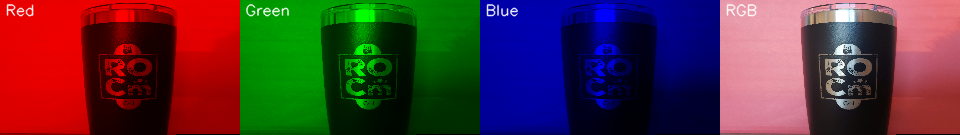

In [5]:
display_rgb_row(tensor_red, tensor_green, tensor_blue)